In [2]:
!nvidia-smi

Sat Mar 14 20:21:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P0             12W /   60W |      14MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### check cuda 

In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.5.1+cu118
True


In [5]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter


#### Load dataset

In [18]:
DATASET_PATH = "dataset"
trafic_path = os.path.join(DATASET_PATH, "trafic-1")

with open(f"{trafic_path}/data.yaml", "r") as f:
    data = yaml.safe_load(f)

print("classes:", data["nc"])
print("class name :", data["names"])

classes: 5
class name : ['bus', 'cars', 'person', 'truck', 'van']


##### quantity check

In [19]:
for split in ["train", "valid", "test"]:
    img_dir = Path(trafic_path) / split / "images"
    if img_dir.exists():
        count = len(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))
        print(f"{split}: {count} ảnh")

train: 738 ảnh
valid: 71 ảnh
test: 35 ảnh


In [20]:
def count_classes(label_dir, class_names):
    counter = Counter()
    for txt_file in Path(label_dir).glob("*.txt"):
        with open(txt_file) as f:
            for line in f:
                class_id = int(line.split()[0])
                counter[class_names[class_id]] += 1
    return counter

class_names = data["names"]

for split in ["train", "valid"]:
    label_dir = Path(trafic_path) / split / "labels"
    if label_dir.exists():
        counts = count_classes(label_dir, class_names)
        print(f"\n{split}:")
        for name, cnt in sorted(counts.items(), key=lambda x: -x[1]):
            print(f"  {name}: {cnt} objects")


train:
  cars: 12561 objects
  truck: 119 objects
  bus: 18 objects
  person: 15 objects
  van: 9 objects

valid:
  cars: 1277 objects
  truck: 10 objects
  van: 1 objects
  bus: 1 objects


##### Visualizetion classes in dataset

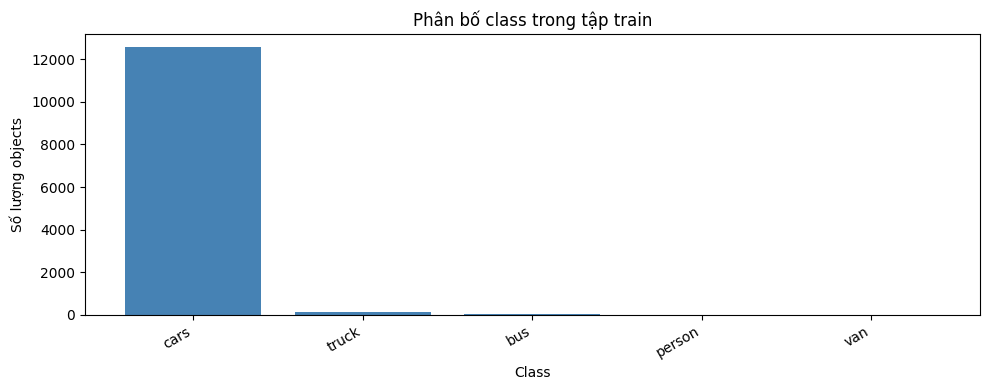

In [21]:
counts = count_classes(
    Path(trafic_path) / "train" / "labels",
    class_names
)

plt.figure(figsize=(10, 4))
plt.bar(counts.keys(), counts.values(), color="steelblue")
plt.title("Phân bố class trong tập train")
plt.xlabel("Class")
plt.ylabel("Số lượng objects")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
def show_image_with_boxes(image_path, label_path, class_names):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)

    colors = plt.cm.get_cmap("tab10", len(class_names))

    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])

                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                box_w = bw * w
                box_h = bh * h

                rect = patches.Rectangle(
                    (x1, y1), box_w, box_h,
                    linewidth=2,
                    edgecolor=colors(cls_id),
                    facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 4,
                        class_names[cls_id],
                        color=colors(cls_id),
                        fontsize=11,
                        fontweight="bold")

    ax.axis("off")
    plt.tight_layout()
    plt.show()


##### check images random 

/tmp/ipykernel_42743/1869269007.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(class_names))


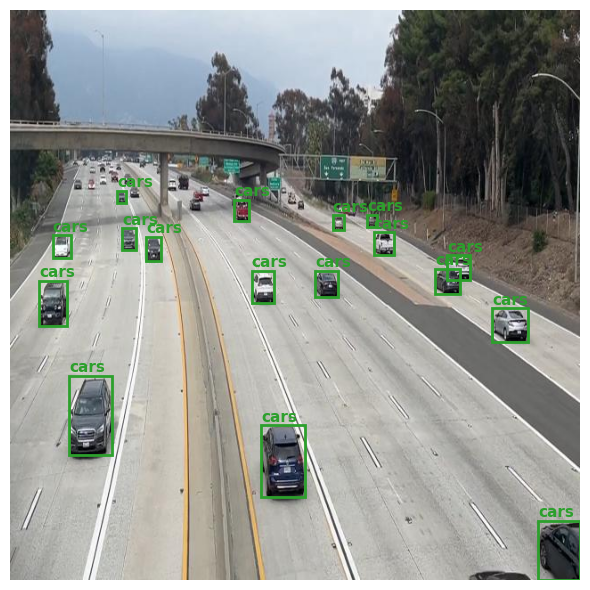

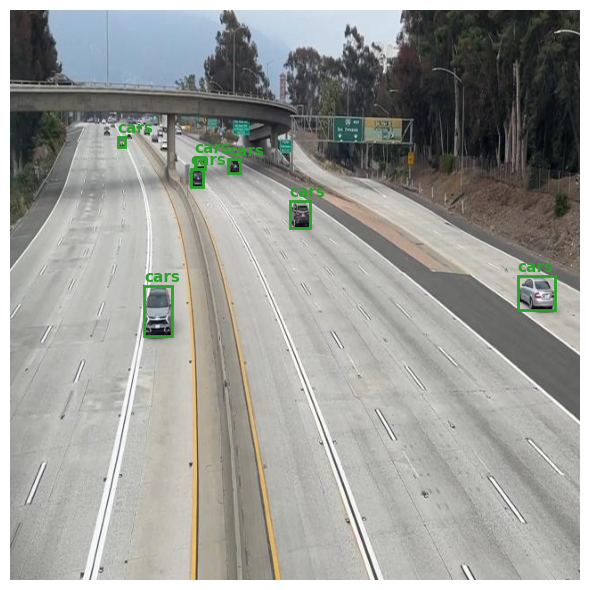

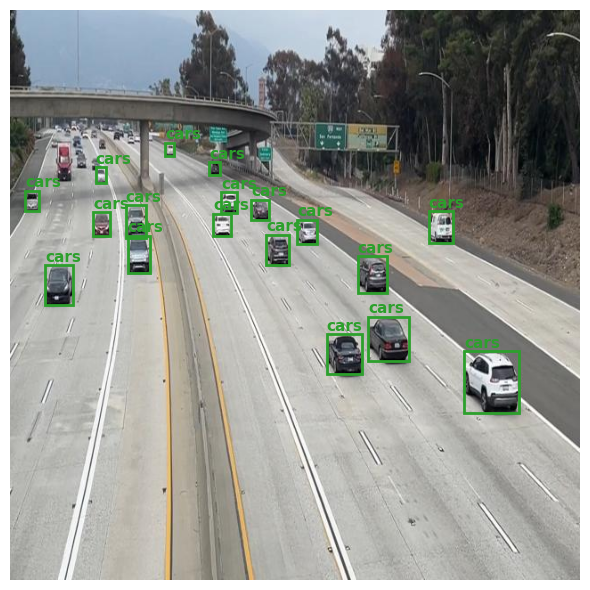

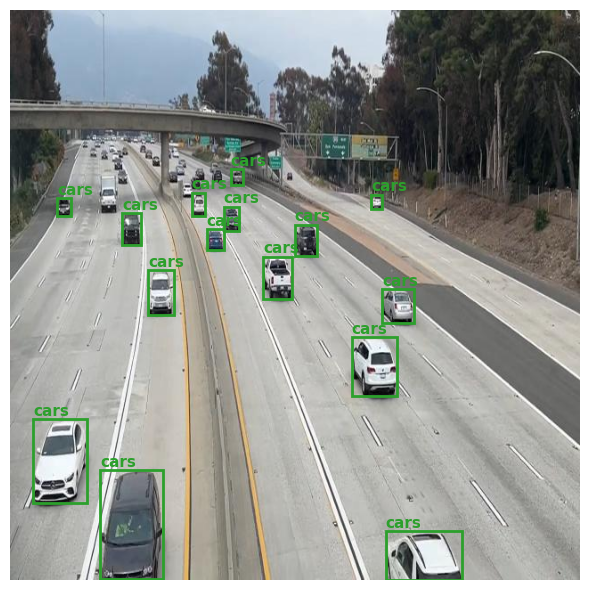

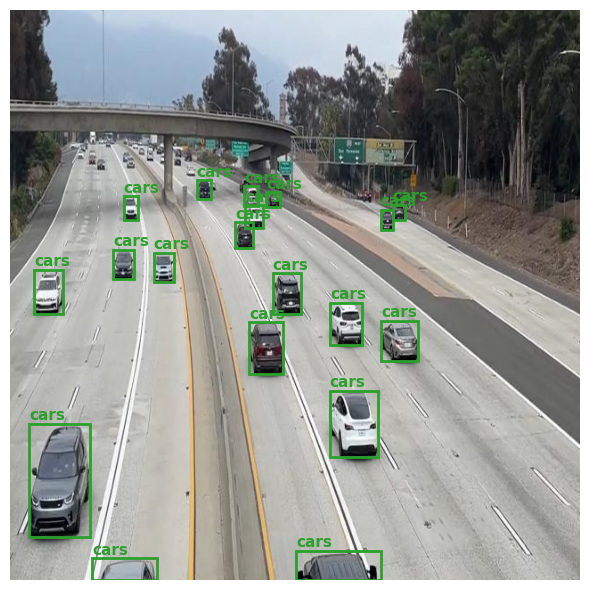

In [24]:
import random

img_dir = Path(trafic_path) / "train" / "images"
lbl_dir = Path(trafic_path) / "train" / "labels"

sample_imgs = random.sample(list(img_dir.glob("*.jpg")), k =5)

for img_path in sample_imgs:
    label_path = lbl_dir / (img_path.stem + ".txt")
    show_image_with_boxes(img_path, label_path, class_names)

In [25]:
img_dir = Path(trafic_path) / "train" / "images"
lbl_dir = Path(trafic_path) / "train" / "labels"

missing = []
for img in img_dir.glob("*.jpg"):
    if not (lbl_dir / (img.stem + ".txt")).exists():
        missing.append(img.name)

print(f"Ảnh thiếu label: {len(missing)}")
if missing:
    print(missing[:10])

Ảnh thiếu label: 0


In [26]:
from ultralytics import YOLO
import torch

print("GPU:", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.0 GB


In [27]:
def setup_device():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    return device

In [29]:
model = YOLO("yolo26n.pt")
results = model.train(
    data= f"{trafic_path}/data.yaml",
    epochs=50,          
    imgsz=640,         
    batch=16,          
    device=0,        
    patience=10,        
    save=True,
    project="runs/detect",
    name="my_model_v1",

    hsv_h=0.015,
    hsv_s=0.7,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.5,
)


New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.9 🚀 Python-3.9.23 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3770MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/trafic-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, na

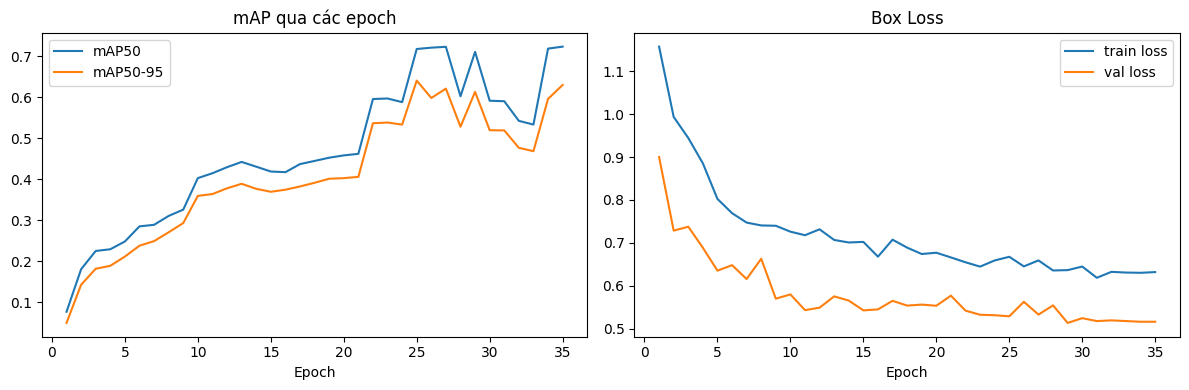

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../fine_tuning_yolo26/runs/detect/runs/detect/my_model_v1/results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[0].set_title("mAP qua các epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(df["epoch"], df["train/box_loss"], label="train loss")
axes[1].plot(df["epoch"], df["val/box_loss"], label="val loss")
axes[1].set_title("Box Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [44]:
best_model = YOLO("../fine_tuning_yolo26/runs/detect/runs/detect/my_model_v1/weights/best.pt")

metrics = best_model.val(data=f"{trafic_path}/data.yaml", device=0)

print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision:{metrics.box.mp:.4f}")
print(f"Recall:   {metrics.box.mr:.4f}")

Ultralytics 8.4.9 🚀 Python-3.9.23 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3770MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 375.6±89.4 MB/s, size: 66.1 KB)
val: Scanning /home/thanh-phuc/PycharmProjects/serving_object_detection/fine_tuning_yolo26/dataset/trafic-1/valid/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 16.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.0it/s 2.5s0.8s
                   all         71       1289      0.902      0.457      0.718      0.641
                   bus          1          1          1          0      0.995      0.895
                  cars         71       1277      0.931      0.926      0.977      0.873
                 truck          9         10      0.678        0.9      0.899      0.793
                   van          1      